# H2 — Does timing (half-life > latency) change how much of the gap survives?

**Outcome.** The *retained gap* $R_i = b_{\ell,i} - c$ (here $c = 0$): the basis still open when the transfer settles, $\ell_i$ being the median episode latency after entry. The *closure* $C_i = b_{0,i} - b_{\ell,i}$ is its mirror image, $R_i = b_{0,i} - C_i$.
**Model.** $R_i = \alpha + \theta\thinspace  b_{0,i} + \delta\thinspace  I_i + \eta\thinspace (b_{0,i} I_i) + \gamma_1 G_i + \gamma_2 S_i + \varepsilon_i$ with $I_i = \mathbf 1\lbrace \tau_{1/2} > \ell_i\rbrace $ ($\tau_{1/2}$ the OU half-life) and day-clustered standard errors. $\eta > 0$ means more of the gap survives to settlement when the half-life exceeds the latency.

**Caveat.** Latency in the panel is a simulated iid lognormal draw (median ≈ 90 s), so this tests the *mechanism* (decay of the proxy basis over the latency window), not real bridge behaviour.

In [1]:
import warnings

import pandas as pd
from IPython.display import Image, display

from crosschain_arb import plots
from crosschain_arb.config import FIGURES_DIR

pd.options.display.float_format = "{:,.4f}".format


def show(path):
    display(Image(filename=str(path)))

In [2]:
from crosschain_arb.episodes import add_roi, add_timing_indicator, attach_future_basis, build_gap_episodes
from crosschain_arb.halflife import ar1_half_life
from crosschain_arb.io import load_panel
from crosschain_arb.models import fit_h2
from crosschain_arb.panel import add_gas_spike

panel = add_gas_spike(load_panel())
tau = ar1_half_life(panel.set_index("time")["basis_t"]).half_life_s
base = add_timing_indicator(attach_future_basis(build_gap_episodes(panel, min_seconds=5.0), panel), tau)
print(f"half-life {tau:.2f}s | episodes {len(base):,} | treated (I = 1): {int(base.timing_I.sum())}")
print(f"median episode latency: {base.latency_med.median():.1f}s")

half-life 9.97s | episodes 17,988 | treated (I = 1): 2
median episode latency: 90.7s


## Estimates

In [3]:
out = {}
for definition in ("retained", "closure"):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        fit = fit_h2(add_roi(base, definition))
    out[definition] = {**fit.to_dict(), "warning": caught[0].message.args[0] if caught else ""}
pd.DataFrame(out).T

,n,n_treated,level,slope_untreated,interaction,se_interaction,p_interaction,coefficients,slope_treated,warning
retained,17988,2,-0.3710,0.4137,0.4585,0.0589,0.0000,"{'Intercept': {'coef': 0.48884379139585343, 's...",0.8722,only 2 treated episodes (timing_I == 1) out of...
closure,17988,2,0.3710,0.5863,-0.4585,0.0589,0.0000,"{'Intercept': {'coef': -0.48884379139583667, '...",0.1278,only 2 treated episodes (timing_I == 1) out of...


In this main specification (episodes of at least 5 s) the interaction is positive for the retained gap (equivalently negative for closure), but its sign depends on the minimum episode duration (notebook 06: it is negative when every episode is used), and only **2** of 17,988 episodes are in that group, because a ≈ 10 s half-life is rarely longer than a ≈ 90 s latency. The standard error is therefore not informative and `fit_h2` warns about it. Observed transfers are faster than the simulated draws (median 49 s) but only 0.01% settle within 10 s, so the group would stay tiny with observed latencies as well. Notebook 06 varies the half-life grid to enlarge the treated group (753 episodes at 5 s): the interaction is then +0.16 and not significant.

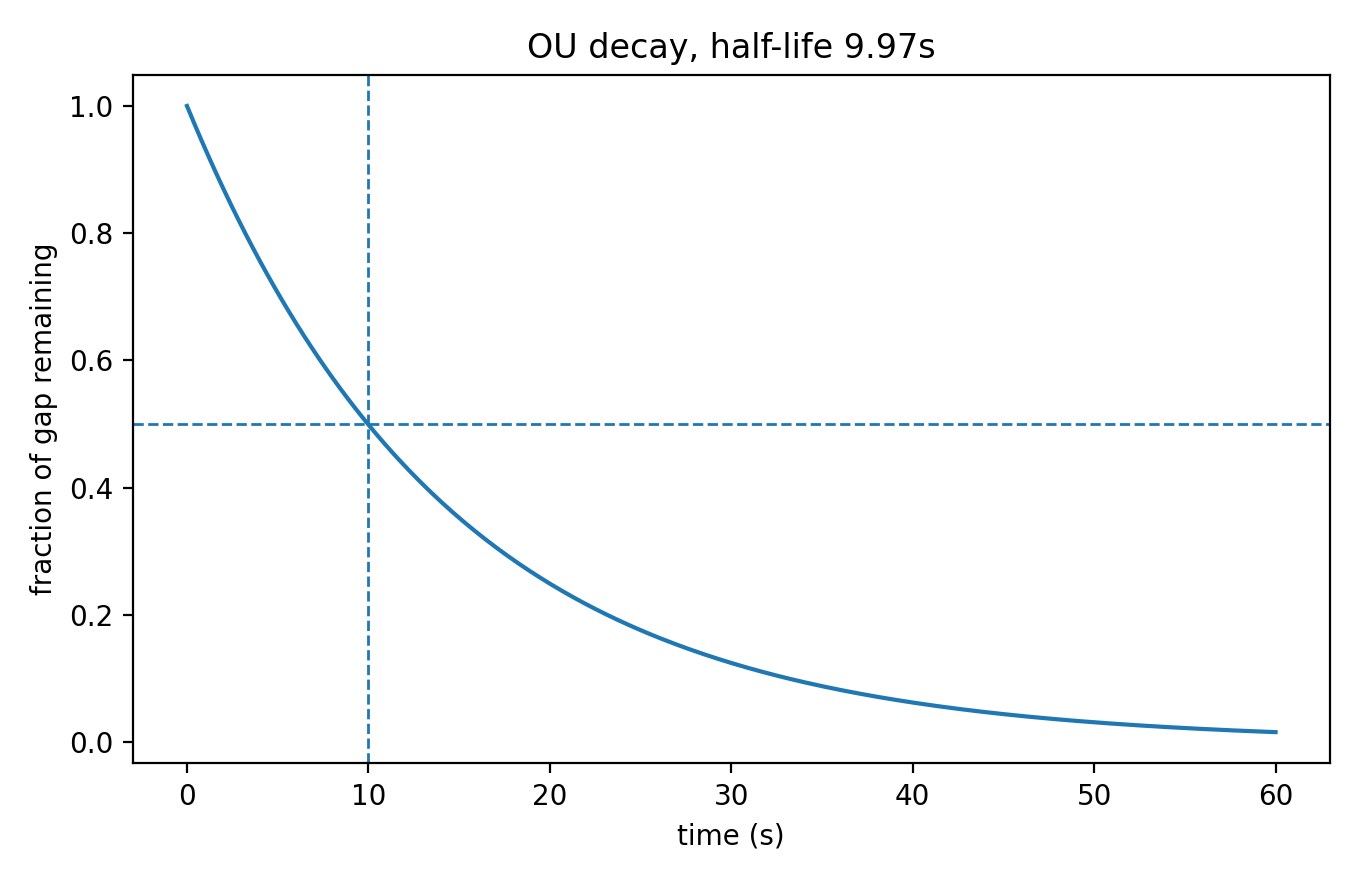

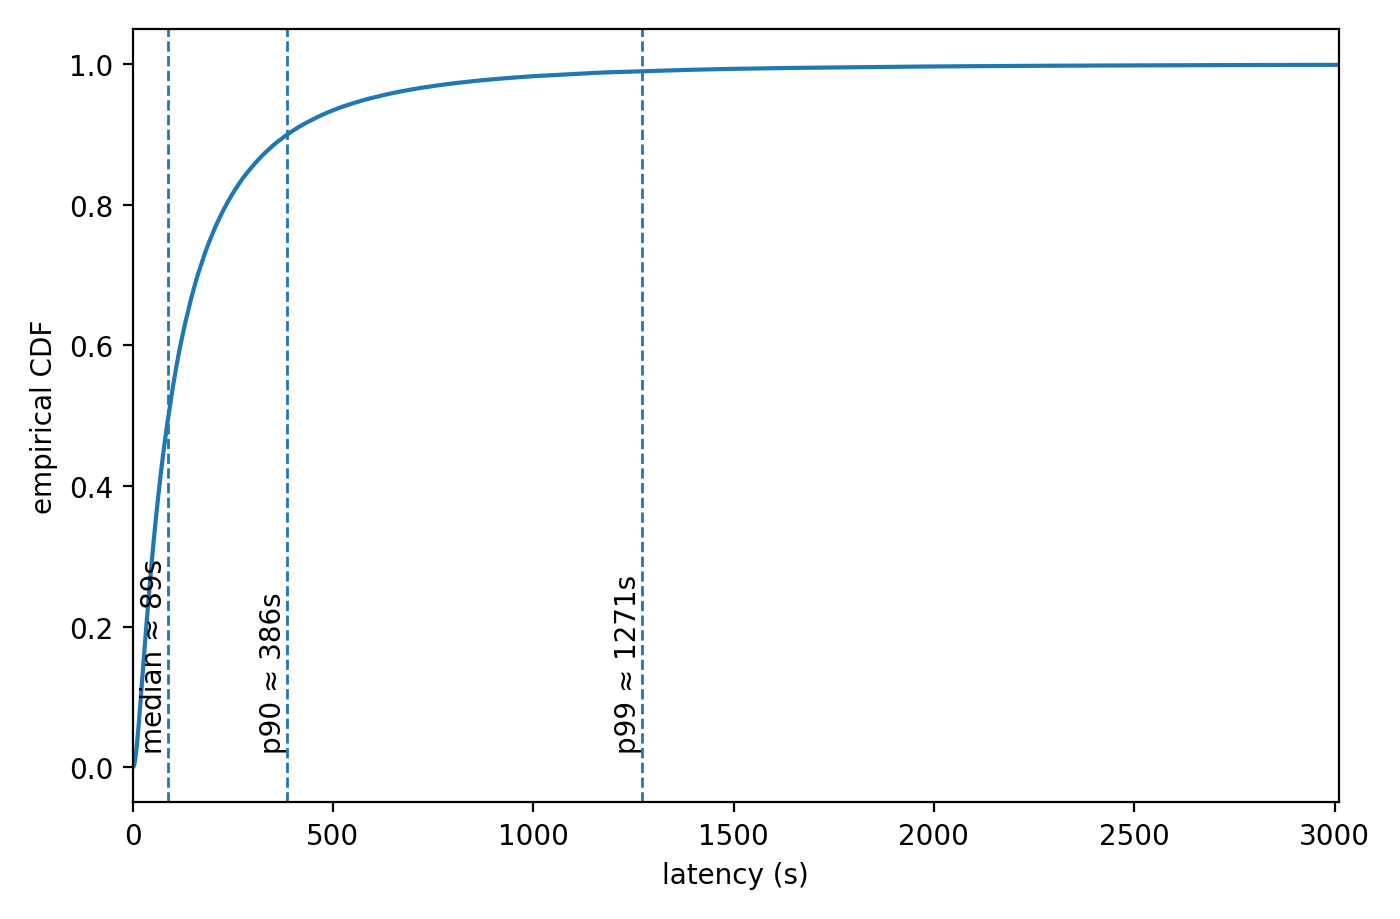

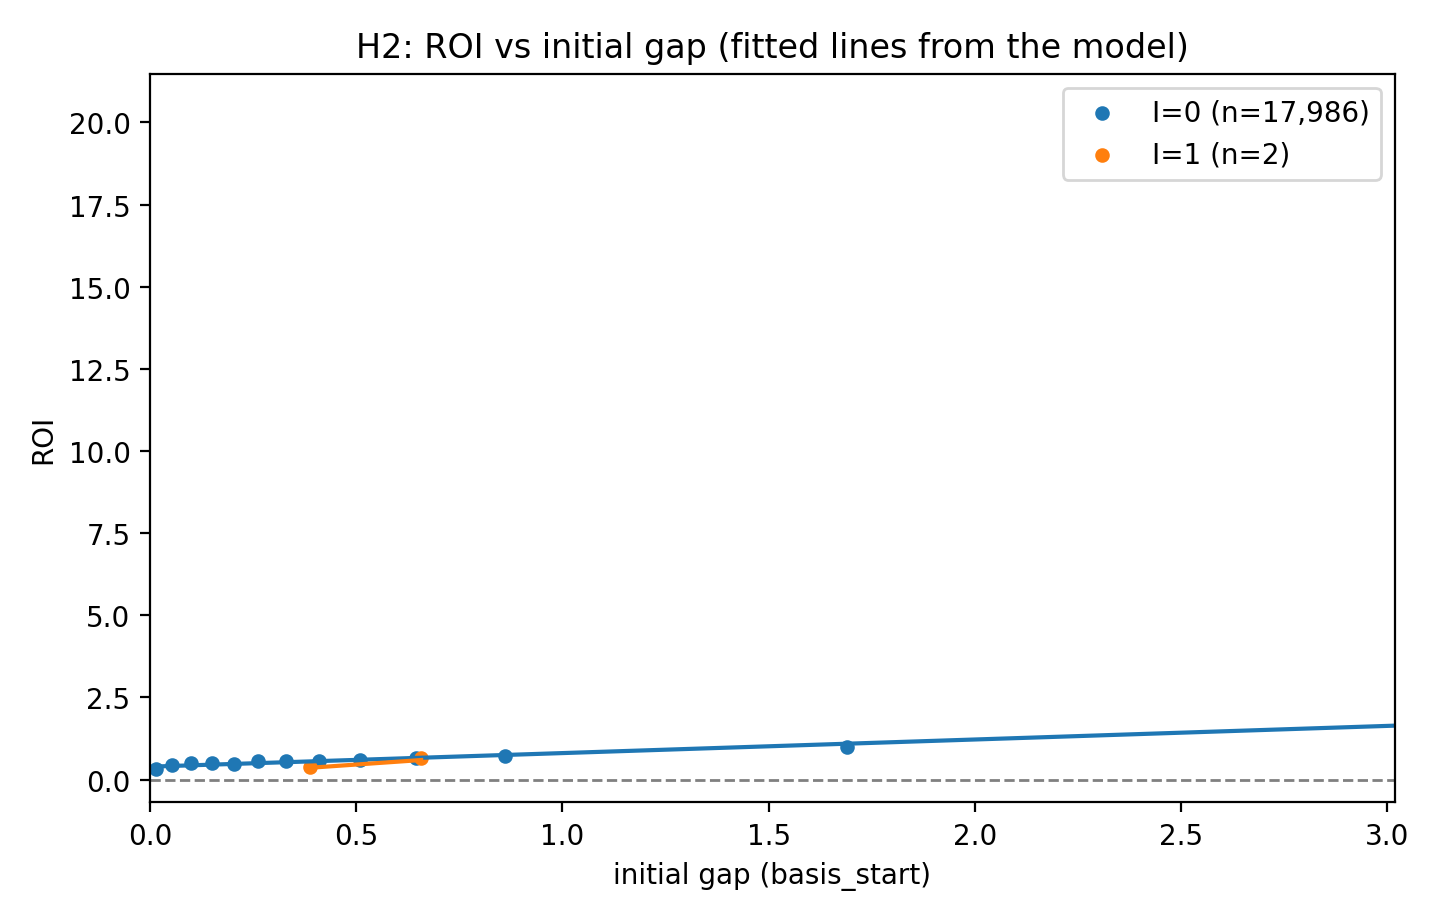

In [4]:
show(plots.plot_ou_decay(tau, FIGURES_DIR / "h2_ou_decay.png"))
show(plots.plot_latency_cdf(panel["latency_t"], FIGURES_DIR / "h2_latency_cdf.png"))
show(plots.plot_h2_roi_vs_gap(add_roi(base, "retained"), FIGURES_DIR / "h2_roi_vs_gap.png"))